# Part 1: EUROSTAT API Extraction
Extracting exact macroeconomic factors for the Euro Area.

In [5]:
import os
import pandas as pd
import eurostat
import warnings
warnings.filterwarnings('ignore')

print("Extracting European Macroeconomic Data via Eurostat API...")

datasets = {
    'Inflation': 'prc_hicp_manr',   
    'Unemployment': 'une_rt_m',   
    'Industrial_Prod': 'sts_inpr_m', 
    'Interest_Rates': 'irt_st_m'   
}

def filter_by_col(df, col_name, allowed_values):
    target_col = next((c for c in df.columns if c.lower() == col_name.lower()), None)
    if target_col:
        filtered_df = df[df[target_col].isin(allowed_values)].copy()
        if filtered_df.empty:
            print(f"    -> WARNING: Filter on {col_name} for {allowed_values} returned empty data.")
        return filtered_df
    return df

macro_dataframes = []

for name, code in datasets.items():
    print(f"Downloading {name} ({code})...")
    df = eurostat.get_data_df(code)
    
    geo_col = next((c for c in df.columns if 'geo' in c.lower()), None)
    if geo_col:
        available_geos = [str(g) for g in df[geo_col].unique()]
        target_code = None
        
        for pref in ['EA20', 'EA19', 'EA']:
            if pref in available_geos:
                target_code = pref
                break
                
        if not target_code:
            ea_codes = [g for g in available_geos if g.startswith('EA')]
            if ea_codes:
                target_code = ea_codes[0]
                
        if target_code:
            print(f"  -> Locked onto Geography Code: {target_code}")
            df = df[df[geo_col] == target_code]
        else:
            print(f"  -> WARNING: No Euro Area code found for {name}.")
            continue

    if name == 'Inflation':
        df = filter_by_col(df, 'coicop', ['CP00'])
    elif name == 'Unemployment':
        df = filter_by_col(df, 's_adj', ['SA'])
        df = filter_by_col(df, 'age', ['TOTAL'])
        df = filter_by_col(df, 'sex', ['T'])
        df = filter_by_col(df, 'unit', ['PC_ACT'])
    elif name == 'Industrial_Prod':
        df = filter_by_col(df, 'nace_r2', ['B-D'])
        df = filter_by_col(df, 's_adj', ['SCA']) 
        df = filter_by_col(df, 'unit', ['I21', 'I15'])
    elif name == 'Interest_Rates':
        intrt_col = next((c for c in df.columns if 'intrt' in c.lower()), None)
        if intrt_col:
            m3_val = [v for v in df[intrt_col].unique() if isinstance(v, str) and v.upper() in ('MAT_M03', 'M3M', 'M03')]
            if m3_val:
                df = df[df[intrt_col] == m3_val[0]]

    date_cols = [c for c in df.columns if str(c)[0].isdigit()]
    meta_cols = [c for c in df.columns if c not in date_cols]
    
    df_melted = df.melt(id_vars=meta_cols, value_vars=date_cols, var_name='Date', value_name=name)
    df_melted['Date'] = df_melted['Date'].astype(str).str.replace('M', '-')
    df_melted['Date'] = pd.to_datetime(df_melted['Date'], errors='coerce')
    
    df_clean = df_melted.dropna(subset=['Date', name])[['Date', name]].set_index('Date')
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    
    macro_dataframes.append(df_clean)

df_macro_master = pd.concat(macro_dataframes, axis=1).sort_index()
df_macro_master = df_macro_master[df_macro_master.index >= '2015-01-01']

print("\nEurostat Extraction Complete. Shape:", df_macro_master.shape)


Extracting European Macroeconomic Data via Eurostat API...
  -> Locked onto Geography Code: EA20
  -> Locked onto Geography Code: EA21
  -> Locked onto Geography Code: EA20
  -> Locked onto Geography Code: EA

Eurostat Extraction Complete. Shape: (137, 4)


In [22]:
# Save a pristine local copy of the Eurostat data
df_macro_master.reset_index().to_csv('../../output/eurostat_macro_data.csv', index=False)
print("Macro data explicitly saved to 'eurostat_macro_data.csv'")

Macro data explicitly saved to 'eurostat_macro_data.csv'


# Part 2: Macroeconomic Indicator Plot

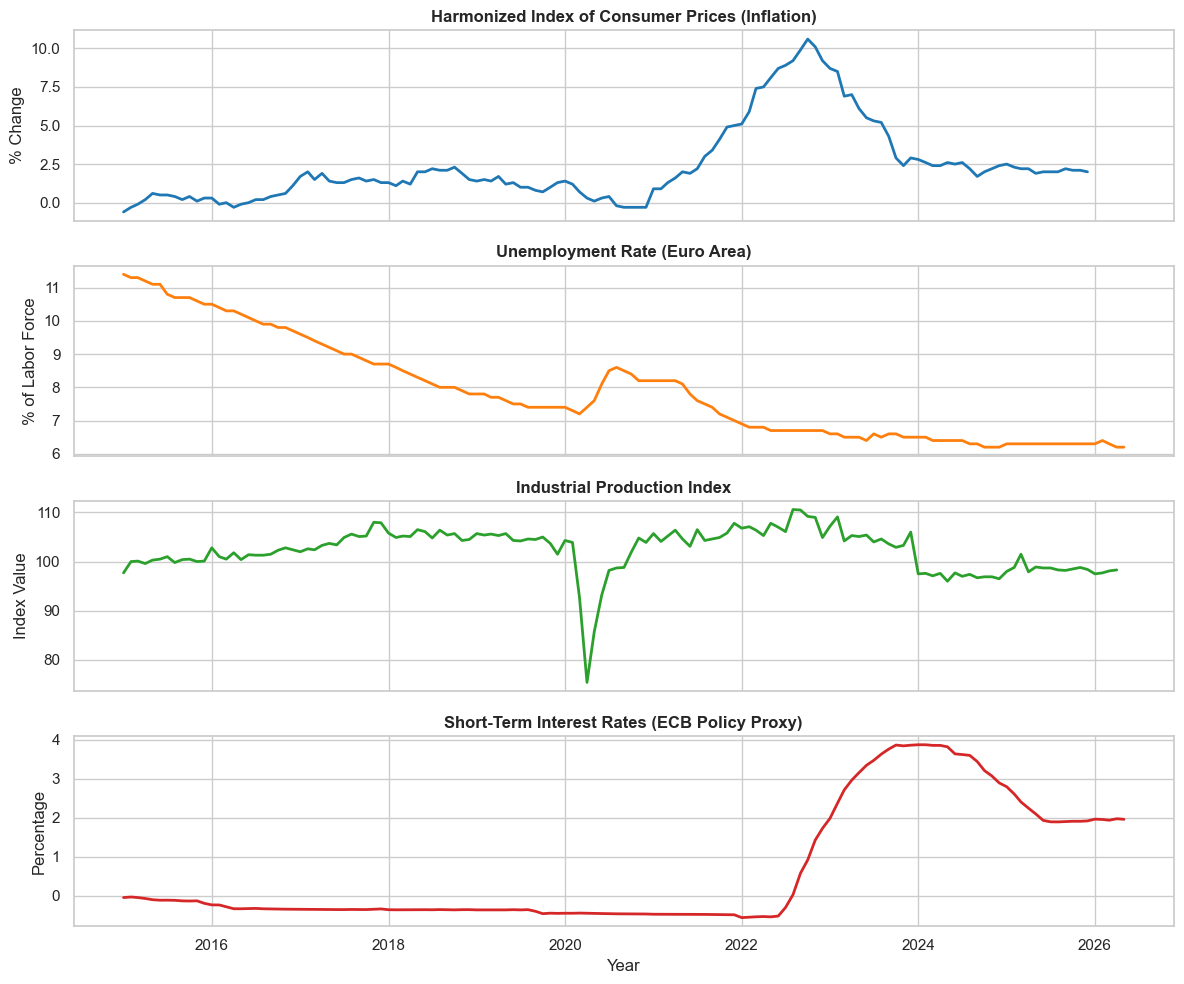

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

axes[0].plot(df_macro_master.index, df_macro_master['Inflation'], color='#1f77b4', linewidth=2)
axes[0].set_title('Harmonized Index of Consumer Prices (Inflation)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Change')

axes[1].plot(df_macro_master.index, df_macro_master['Unemployment'], color='#ff7f0e', linewidth=2)
axes[1].set_title('Unemployment Rate (Euro Area)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of Labor Force')

axes[2].plot(df_macro_master.index, df_macro_master['Industrial_Prod'], color='#2ca02c', linewidth=2)
axes[2].set_title('Industrial Production Index', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Index Value')

axes[3].plot(df_macro_master.index, df_macro_master['Interest_Rates'], color='#d62728', linewidth=2)
axes[3].set_title('Short-Term Interest Rates (ECB Policy Proxy)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Percentage')

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

# Part 3: FinBERT and Semantic Index

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from datetime import datetime
import pandas as pd
from tqdm import tqdm
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

C:\Users\zahra\AppData\Roaming\Python\Python38\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using compute device: cuda
GPU Name: NVIDIA GeForce GTX 960M


Loading FinBERT Model with Explicit Evaluation Mode

In [3]:
# Only first time

# import os
# import urllib.request

# local_model_path = "D:/PML/huggingface_data/finbert_local"

# # Create the folder if it doesn't exist
# os.makedirs(local_model_path, exist_ok=True)

# # The core files required for FinBERT sequence classification
# files_to_download = [
#     "config.json",
#     "pytorch_model.bin",
#     "vocab.txt",
#     "special_tokens_map.json",
#     "tokenizer_config.json"
# ]

# base_url = "https://huggingface.co/ProsusAI/finbert/resolve/main/"

# print("Bypassing HF cache: Downloading model files directly...")

# for file in files_to_download:
#     url = base_url + file
#     save_path = os.path.join(local_model_path, file)
    
#     if not os.path.exists(save_path):
#         print(f"Downloading {file}...")
#         try:
#             urllib.request.urlretrieve(url, save_path)
#             print(f"  -> Successfully saved {file}")
#         except Exception as e:
#             print(f"  -> Error downloading {file}: {e}")
#     else:
#         print(f"Already exists: {file}")

# print("\nDirect download complete!")

In [2]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# Point exactly to the local folder we just downloaded to
local_model_path = "D:/PML/huggingface_data/finbert_local"

tokenizer = AutoTokenizer.from_pretrained(local_model_path)
model = AutoModelForSequenceClassification.from_pretrained(local_model_path).to(device)

# Force model into inference mode
model.eval()

def get_sentiment_batch(text_list):
    # Max length bounded to 128 to strictly respect VRAM limits
    inputs = tokenizer(text_list, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    
    with torch.no_grad(): # Explicitly blocks PyTorch from storing gradients
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)
    
    # Calculate Positive - Negative (Moving values to CPU memory immediately)
    scores = (probs[:, 0] - probs[:, 1]).cpu().tolist()
    
    # Memory Scrubber: Delete massive tensors from GPU explicitly
    del inputs
    del outputs
    del probs
    
    return scores 

Using compute device: cuda


Local Disk Loading and RAM-Safe Chunking

In [3]:
# only if you want to download data from huggingface first time

# import os
# from datasets import load_dataset

# custom_cache_path = "D:/PML/huggingface_data"

# # Create the folder if it doesn't exist yet
# if not os.path.exists(custom_cache_path):
#     os.makedirs(custom_cache_path)

# print(f"Downloading / Loading dataset directly to {custom_cache_path}...")

# dataset = load_dataset(
#     "Brianferrell787/financial-news-multisource", 
#     name="data",
#     split="train",
#     cache_dir=custom_cache_path,
#     use_auth_token="Your Token Here",

# )

macro_keywords = [
    'ecb', 'fed', 'federal reserve', 'central bank', 'interest rate', 'rates', 
    'lagarde', 'powell', 'monetary policy', 'fiscal policy', 'stimulus', 'budget', 
    'tax', 'government spending', 'sovereign debt', 'deficit', 'treasury', 'bond', 
    'hawkish', 'doveish', 'quantitative easing', 'inflation', 'deflation', 'cpi', 
    'hicp', 'gdp', 'recession', 'economy', 'economic', 'unemployment', 'employment', 
    'jobs', 'wage', 'labor', 'supply chain', 'shortage', 'bottleneck', 'logistics', 
    'commodity', 'oil', 'gas', 'energy', 'crude', 'brent', 'electricity', 'agriculture', 
    'grain', 'food prices', 'banking', 'credit crunch', 'contagion', 'bailout', 
    'default', 'bankruptcy', 'insolvency', 'housing market', 'real estate', 'mortgage', 
    'property crash', 'war', 'conflict', 'geopolitical', 'sanctions', 'tariff', 
    'trade war', 'embargo', 'strike', 'election', 'virus', 'pandemic', 'lockdown', 
    'crisis', 'crash', 'collapse', 'uncertainty'
]

In [5]:
import os
import gc
import glob
import pandas as pd
import torch
from tqdm import tqdm

CACHE_DIR     = "D:/PML/huggingface_data/downloads"
OUTPUT_CSV    = "../../output/daily_headlines_with_semantics.csv"
PROGRESS_FILE = "../../output/processed_blobs.txt"   # checkpoint tracker
BATCH_SIZE    = 128    
CHUNK_SIZE    = 5000    

# ── CHECKPOINT HELPERS
def load_progress():
    """Return the set of blob filenames already fully processed."""
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE, 'r') as f:
            return set(line.strip() for line in f if line.strip())
    return set()

def mark_done(blob_name):
    """Append blob_name to the progress file."""
    with open(PROGRESS_FILE, 'a') as f:
        f.write(blob_name + '\n')

def flush_chunk(chunk_data, output_csv):
    """Write chunk_data list to CSV (append mode), free RAM, return empty list."""
    if not chunk_data:
        return []
    df = pd.DataFrame(chunk_data)
    write_header = not os.path.exists(output_csv)
    df.to_csv(output_csv, mode='a', header=write_header, index=False)
    del df
    gc.collect()
    return []

# ── SETUP 
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

already_done = load_progress()
all_files    = sorted(glob.glob(os.path.join(CACHE_DIR, "*")))
total_files  = sum(1 for f in all_files
                   if not f.endswith(".json")
                   and os.path.getsize(f) / (1024 * 1024) > 10)

chunk_data   = []
total_saved  = 0
blobs_done   = 0

print(f"Found {total_files} data blobs.  {len(already_done)} already completed.")
print(f"Output  → {OUTPUT_CSV}")
print(f"Checkpoint → {PROGRESS_FILE}")
print("=" * 60)

# ── MAIN LOOP: one blob at a time 
for file_path in all_files:
    blob_name    = os.path.basename(file_path)
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

    # Skip metadata stubs and tiny files
    if blob_name.endswith(".json") or file_size_mb <= 10:
        continue

    # Skip blobs that were already fully processed in a previous run
    if blob_name in already_done:
        print(f"  [SKIP] {blob_name[:20]}...  (already done)")
        blobs_done += 1
        continue

    print(f"\n[{blobs_done+1}/{total_files}] {blob_name[:20]}...  ({file_size_mb:.0f} MB)")

    # ── STEP 1: Read only the two columns we need
    try:
        df_shard = pd.read_parquet(file_path, engine='pyarrow', columns=['date', 'text'])
    except Exception as e:
        print(f"  -> Unreadable: {e}  — skipping")
        continue

    # ── STEP 2: Date filter (2015-2025)
    df_shard['date'] = pd.to_datetime(df_shard['date'], errors='coerce', utc=True)
    df_shard = df_shard.dropna(subset=['date', 'text'])
    df_shard = df_shard[
        (df_shard['date'].dt.year >= 2015) &
        (df_shard['date'].dt.year <= 2025)
    ]

    # ── STEP 3: Keyword filter (macro-relevant only)
    kw_pattern   = '|'.join(macro_keywords)
    kw_mask      = df_shard['text'].str.lower().str.contains(kw_pattern, regex=True, na=False)
    df_filtered  = df_shard[kw_mask].reset_index(drop=True)

    # Free the full shard immediately — keep only the small filtered slice
    del df_shard
    gc.collect()

    n_relevant = len(df_filtered)
    print(f"  -> {n_relevant:,} macro-relevant rows after filtering")

    if n_relevant == 0:
        mark_done(blob_name)      
        blobs_done += 1
        continue

    # ── STEP 4: FinBERT scoring (GPU)
    texts = df_filtered['text'].tolist()
    dates = df_filtered['date'].dt.date.tolist()
    del df_filtered
    gc.collect()

    batch_texts, batch_dates = [], []
    blob_saved = 0

    for text, date in tqdm(zip(texts, dates),
                           total=len(texts),
                           desc="    FinBERT",
                           leave=False):
        batch_texts.append(text)
        batch_dates.append(date)

        if len(batch_texts) >= BATCH_SIZE:
            scores = get_sentiment_batch(batch_texts)
            for d, t, s in zip(batch_dates, batch_texts, scores):
                chunk_data.append({'Date': d, 'Headline': t, 'FinBERT_Score': s})
            batch_texts, batch_dates = [], []

            # Mid-blob flush: protects VRAM and keeps chunk_data small
            if len(chunk_data) >= CHUNK_SIZE:
                chunk_data = flush_chunk(chunk_data, OUTPUT_CSV)
                torch.cuda.empty_cache()
                blob_saved += CHUNK_SIZE
                total_saved += CHUNK_SIZE

    # Process the final partial batch
    if batch_texts:
        scores = get_sentiment_batch(batch_texts)
        for d, t, s in zip(batch_dates, batch_texts, scores):
            chunk_data.append({'Date': d, 'Headline': t, 'FinBERT_Score': s})

    # ── STEP 5: Flush remaining results & mark blob complete 
    # NOTE: mark_done() is called AFTER the flush.
    # If the kernel crashes before this line, the blob is NOT marked done
    # → it will be cleanly reprocessed on restart (no duplicates in CSV).
    chunk_data = flush_chunk(chunk_data, OUTPUT_CSV)
    blob_saved += n_relevant - (blob_saved % CHUNK_SIZE if blob_saved else 0)
    total_saved += blob_saved % CHUNK_SIZE if blob_saved else n_relevant
    mark_done(blob_name)

    blobs_done += 1
    print(f"  [SAVED] blob complete. Cumulative rows saved: {total_saved:,}")

print(f"\n{'='*60}")
print(f"✅ Pipeline complete!")
print(f"   Blobs processed : {blobs_done}/{total_files}")
print(f"   Output file     : {OUTPUT_CSV}")


Found 124 data blobs.  3 already completed.
Output  → ../../output/daily_headlines_with_semantics.csv
Checkpoint → ../../output/processed_blobs.txt
  [SKIP] 00acf85d0402814f91ba...  (already done)
  [SKIP] 02f37e50d3ef77f5c1a4...  (already done)
  [SKIP] 06162638192e94510253...  (already done)

[4/124] 08e0abaa2beb3cf7168e...  (100 MB)
  -> 129,654 macro-relevant rows after filtering


  [SAVED] blob complete. Cumulative rows saved: 129,654

[5/124] 0959c8402a9228b307dc...  (180 MB)
  -> 0 macro-relevant rows after filtering

[6/124] 0b488da6769fefd3914f...  (46 MB)
  -> 18,790 macro-relevant rows after filtering


  [SAVED] blob complete. Cumulative rows saved: 148,444

[7/124] 0b7f53083f4ab3a23270...  (42 MB)
  -> 0 macro-relevant rows after filtering

[8/124] 0d96886d8f81f40ee692...  (141 MB)
  -> 31,915 macro-relevant rows after filtering


  [SAVED] blob complete. Cumulative rows saved: 180,359

[9/124] 0ef9817c590fb1b31afb...  (132 MB)
  -> 0 macro-relevant rows after filtering

[10/124] 0f1748b84c90507ab571...  (1041 MB)
  -> 371,438 macro-relevant rows after filtering


KeyboardInterrupt: 

# Part 4: Aggregate daily news into Monthly Exponential Moving Average

In [ ]:
print("Loading safe local file and compressing daily tensors into monthly EMA...")

# Load the pristine output file back in for aggregation
df_news = pd.read_csv('daily_headlines_with_semantics.csv')
df_news['Date'] = pd.to_datetime(df_news['Date'])
df_news = df_news.drop_duplicates(subset=['Headline'])

df_daily = df_news.groupby('Date')['FinBERT_Score'].mean().reset_index()
df_daily.set_index('Date', inplace=True)

df_monthly_sentiment = df_daily.resample('ME').mean().ewm(span=30, adjust=False).mean()
df_monthly_sentiment.rename(columns={'FinBERT_Score': 'FinBERT_EMA'}, inplace=True)
df_monthly_sentiment['FinBERT_EMA'] = df_monthly_sentiment['FinBERT_EMA'].shift(1)
df_monthly_sentiment = df_monthly_sentiment.dropna()

print("Monthly sentiment successfully calculated.")

# Part 5: Merge two datasets

In [ ]:
import pandas as pd

print("Loading saved Eurostat Macro Data...")
# 1. Load the local macro data saved from Part 1
df_macro_master = pd.read_csv('eurostat_macro_data_local.csv')
df_macro_master['Date'] = pd.to_datetime(df_macro_master['Date'])
df_macro_master.set_index('Date', inplace=True)

print("Merging Eurostat Macro Data with NLP Sentiment Data...")
# 2. Strip timezones to prevent merge conflicts
df_macro_master.index = df_macro_master.index.tz_localize(None)
df_monthly_sentiment.index = df_monthly_sentiment.index.tz_localize(None)

# 3. Inner merge to align the exact months where both datasets exist
df_final = pd.merge(df_macro_master, df_monthly_sentiment, left_index=True, right_index=True, how='inner')

print(f"Final combined dataset shape: {df_final.shape}")

# Part 6: Save Final Output

In [ ]:
output_filename = 'euro_macro_sentiment_aligned.csv'

# Ensure Date is captured as a column, not lost in the index
df_final_csv = df_final.reset_index()
if 'index' in df_final_csv.columns:
    df_final_csv = df_final_csv.rename(columns={'index': 'Date'})

df_final_csv.to_csv(output_filename, index=False)

print(f"\nSUCCESS! Final merged dataset saved to your local drive as: {output_filename}")